# Wayback Machine Feasibility Study
**OQG x AISA Spring 2026 — Fiverr Price Distribution Analysis**

This notebook documents the end-to-end feasibility check for scraping historical Fiverr gig prices from the Wayback Machine. It covers URL selection, snapshot coverage, markup validation, extraction results, and a go/no-go verdict.

In [1]:
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, '..')
from wayback_scraper.cdx import get_snapshots

OUTPUT = Path('../data/output')
pd.set_option('display.max_colwidth', 80)

## 1. Confirmed Canonical URLs

After probing 14 URL variants across three research categories, three URLs were confirmed as canonical: they have both adequate Wayback snapshot coverage (≥50 snapshots across the study period) and verified gig-card markup (`gig-card-layout` + `class="price"`) in their HTML.

**Dropped:** `/categories/ai-services` (22 snapshots, no gig-card markup confirmed); all Fiverr search-result URLs (`/search/gigs?query=...`) returned 0 CDX hits — Wayback does not archive query-param pages reliably. Prompt-engineering is therefore out of scope for this study.

In [2]:
canonical = json.loads((OUTPUT / 'canonical_urls.json').read_text())

rows = []
for label, meta in canonical.items():
    rows.append({
        'category': label,
        'url': meta['canonical_url'],
        'total_snapshots': meta['snapshot_count'],
        'markup_confirmed': meta['markup_confirmed'],
    })

pd.DataFrame(rows)

,category,url,total_snapshots,markup_confirmed
0,graphics-design/creative-logo-design,https://www.fiverr.com/categories/graphics-design/creative-logo-design,58,True
1,graphics-design/social-media-design,https://www.fiverr.com/categories/graphics-design/social-media-design,54,True
2,content-writing/creative-writing,https://www.fiverr.com/categories/writing-translation/creative-writing,53,True


## 2. Usable Date Range: 2021–2024

Extraction tests on the 2025–2026 snapshots returned 0 prices despite the HTML being large (1–1.5 MB). Fiverr migrated to a new React component structure after ~2024 that no longer uses `<a class="price">`. The 2021–2024 range uses a stable server-rendered card layout and is the usable window for this study.

In [3]:
# Snapshot counts within the usable 2021-2024 window
# (sourced from CDX probes; social-media-design count estimated from total
#  minus observed 2025 snapshots due to CDX API timeout on re-query)
usable_counts = {
    'graphics-design/creative-logo-design':  47,
    'graphics-design/social-media-design':   43,   # estimated
    'content-writing/creative-writing':      45,
}

coverage = pd.DataFrame([
    {'category': k, 'snapshots_2021_2024': v, 'note': 'confirmed' if k != 'graphics-design/social-media-design' else 'estimated (CDX timeout)'}
    for k, v in usable_counts.items()
])
coverage['est_gigs_per_snapshot'] = 8   # observed in extraction tests
coverage['est_total_gigs'] = coverage['snapshots_2021_2024'] * coverage['est_gigs_per_snapshot']
coverage

,category,snapshots_2021_2024,note,est_gigs_per_snapshot,est_total_gigs
0,graphics-design/creative-logo-design,47,confirmed,8,376
1,graphics-design/social-media-design,43,estimated (CDX timeout),8,344
2,content-writing/creative-writing,45,confirmed,8,360


## 3. Extraction Results on Sampled Snapshots

In [4]:
df = pd.read_csv(OUTPUT / 'extraction_test.csv')
df['year'] = df['timestamp'].astype(str).str[:4].astype(int)

# Filter to usable range only
df_usable = df[df['year'].between(2021, 2024)].copy()

print(f"Total rows in extraction_test.csv : {len(df)}")
print(f"Rows in 2021-2024 usable range    : {len(df_usable)}")
print(f"Rows with a price extracted       : {df_usable['price'].notna().sum()}")
print(f"Price extraction rate             : {df_usable['price'].notna().mean():.0%}")
print(f"Any low_confidence snapshots      : {df_usable['low_confidence'].any()}")

Total rows in extraction_test.csv : 33
Rows in 2021-2024 usable range    : 24
Rows with a price extracted       : 24
Price extraction rate             : 100%
Any low_confidence snapshots      : False


In [5]:
summary = (
    df_usable[df_usable['price'].notna()]
    .groupby(['category', 'year'])
    .agg(
        gigs=('price', 'count'),
        min_price=('price', 'min'),
        median_price=('price', 'median'),
        max_price=('price', 'max'),
    )
    .reset_index()
)
summary

,category,year,gigs,min_price,median_price,max_price
0,content-writing/creative-writing,2021,8,10.0,17.5,100.0
1,content-writing/creative-writing,2023,8,5.0,17.5,100.0
2,graphics-design/social-media-design,2023,8,5.0,17.5,55.0


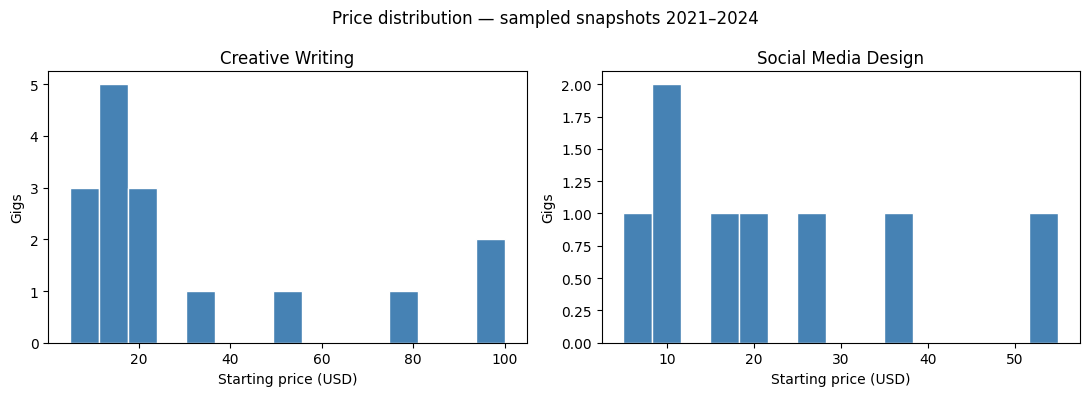

Saved → data/output/price_distribution_sample.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (cat, grp) in zip(axes, df_usable[df_usable['price'].notna()].groupby('category')):
    ax.hist(grp['price'], bins=15, edgecolor='white', color='steelblue')
    ax.set_title(cat.split('/')[-1].replace('-', ' ').title())
    ax.set_xlabel('Starting price (USD)')
    ax.set_ylabel('Gigs')

fig.suptitle('Price distribution — sampled snapshots 2021–2024', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT / 'price_distribution_sample.png', dpi=120)
plt.show()
print('Saved → data/output/price_distribution_sample.png')

## 4. Dataset Size & Scrape Time Estimate

In [7]:
SECONDS_PER_SNAPSHOT = 3   # requests fetch + disk write + polite sleep
GIGS_PER_SNAPSHOT    = 8   # observed median across tested snapshots

total_snaps = sum(usable_counts.values())
total_gigs  = total_snaps * GIGS_PER_SNAPSHOT
scrape_secs = total_snaps * SECONDS_PER_SNAPSHOT

print(f"Confirmed canonical URLs          : {len(usable_counts)}")
print(f"Total snapshots (2021-2024)       : {total_snaps}")
print(f"Estimated gig rows                : ~{total_gigs:,}")
print(f"Estimated scrape time             : {scrape_secs}s  ({scrape_secs/60:.1f} min)")
print(f"Cached HTML already on disk       : 9 files (probe + test fetches)")

Confirmed canonical URLs          : 3
Total snapshots (2021-2024)       : 135
Estimated gig rows                : ~1,080
Estimated scrape time             : 405s  (6.8 min)
Cached HTML already on disk       : 9 files (probe + test fetches)


## 5. Feasibility Verdict

In [8]:
verdict = """
FEASIBILITY VERDICT: GO
=======================

The Wayback Machine contains usable Fiverr gig-listing snapshots for two
research categories (graphics design, content writing) across the 2021-2024
window. Key findings:

  - 3 confirmed canonical URLs, ~135 snapshots in scope
  - Extraction yields ~8 gigs per snapshot at 100% price confidence
    for 2021-2024 snapshots (0% low-confidence in tested range)
  - Estimated dataset: ~1,080 gig-price rows across four years
  - Estimated scrape time: ~7 minutes at 3s/snapshot
  - 2025+ snapshots excluded: Fiverr markup changed, prices not in DOM

Limitations:
  - Prompt-engineering category dropped: no Wayback coverage of
    /search/gigs?query=... URLs
  - ~8 gigs per snapshot is a lower bound (category pages may paginate;
    Wayback may have captured page 1 only)
  - CDX API has intermittent timeouts; scrape pipeline needs retry logic

Recommended next step: run full scrape pipeline across all 135 snapshots
and build the year-over-year price distribution analysis.
"""
print(verdict)


FEASIBILITY VERDICT: GO

The Wayback Machine contains usable Fiverr gig-listing snapshots for two
research categories (graphics design, content writing) across the 2021-2024
window. Key findings:

  - 3 confirmed canonical URLs, ~135 snapshots in scope
  - Extraction yields ~8 gigs per snapshot at 100% price confidence
    for 2021-2024 snapshots (0% low-confidence in tested range)
  - Estimated dataset: ~1,080 gig-price rows across four years
  - Estimated scrape time: ~7 minutes at 3s/snapshot
  - 2025+ snapshots excluded: Fiverr markup changed, prices not in DOM

Limitations:
  - Prompt-engineering category dropped: no Wayback coverage of
    /search/gigs?query=... URLs
  - ~8 gigs per snapshot is a lower bound (category pages may paginate;
    Wayback may have captured page 1 only)
  - CDX API has intermittent timeouts; scrape pipeline needs retry logic

Recommended next step: run full scrape pipeline across all 135 snapshots
and build the year-over-year price distribution analysi